/tmp/ipykernel_1367498/59964060.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
/tmp/ipykernel_13

Pre-trained VAE models loaded successfully.


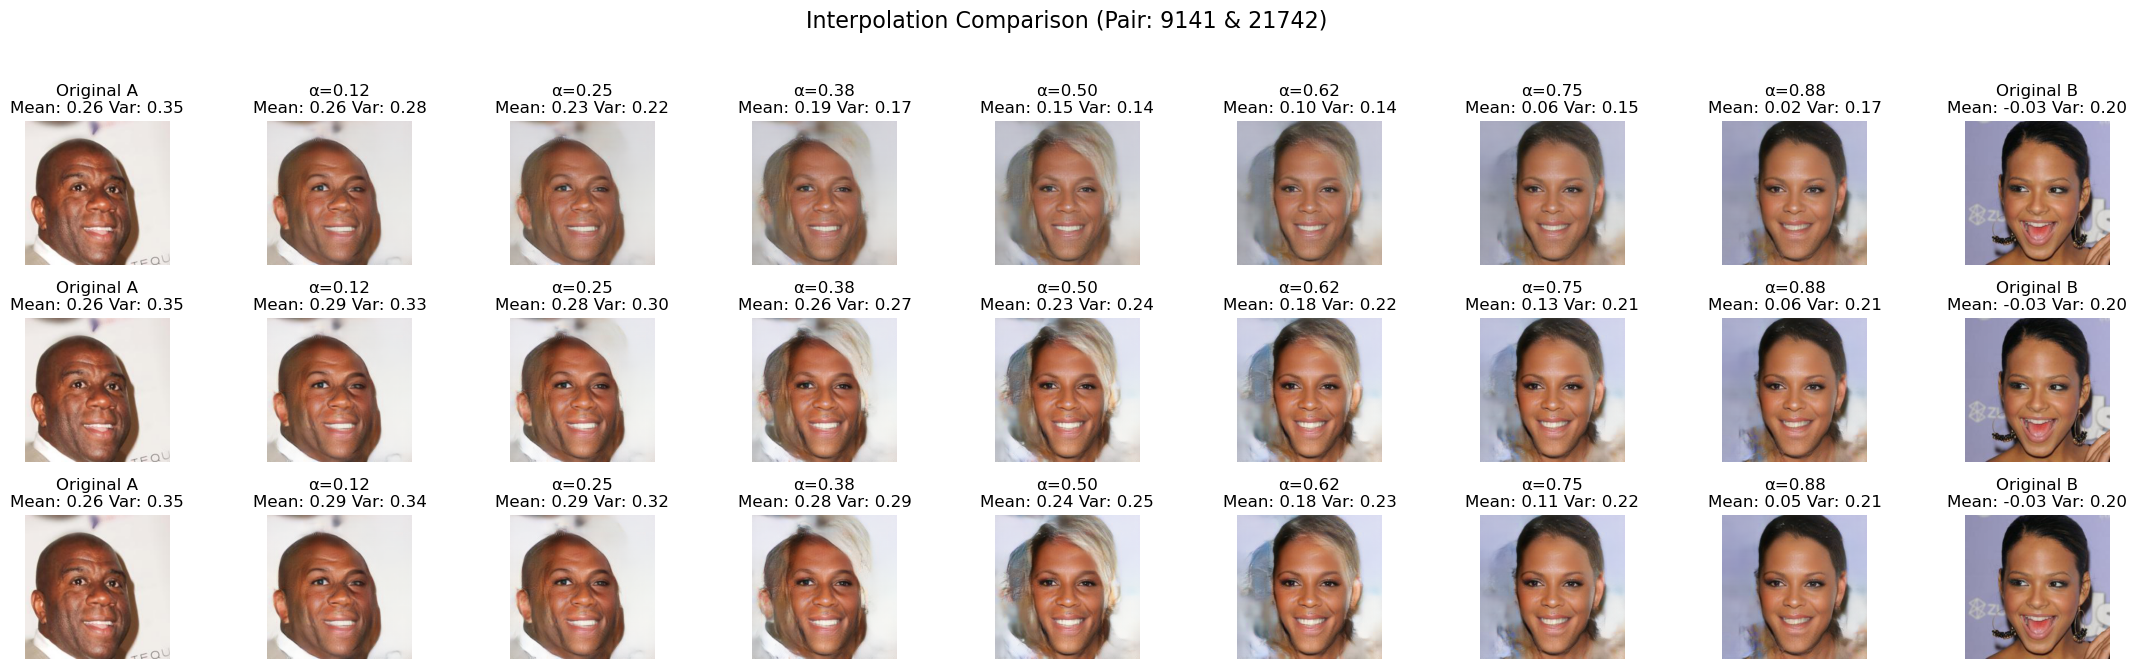

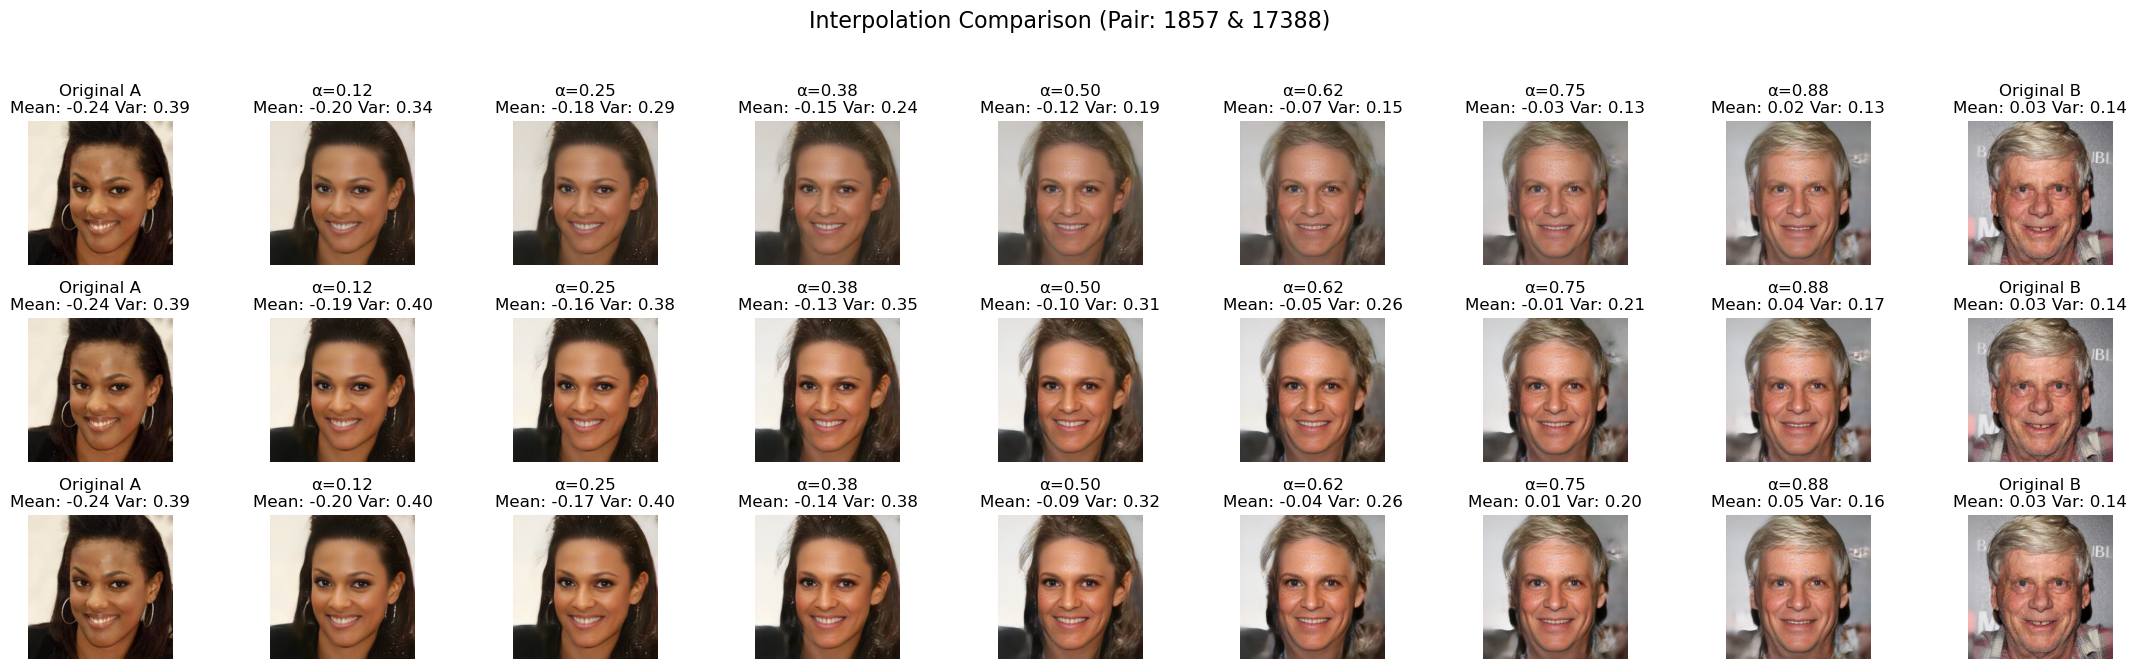

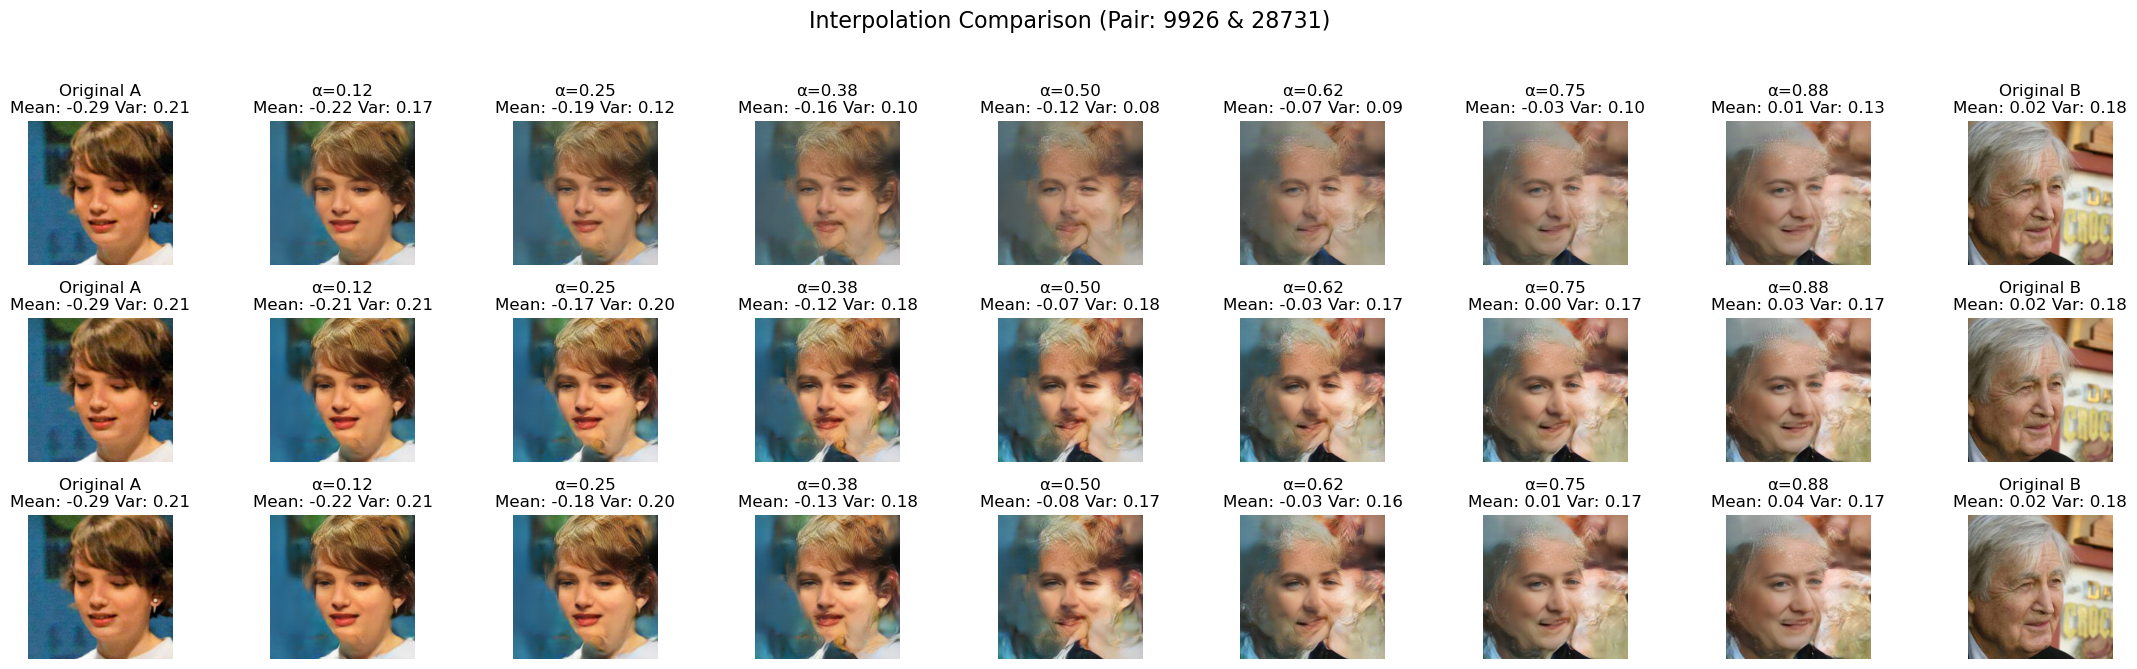

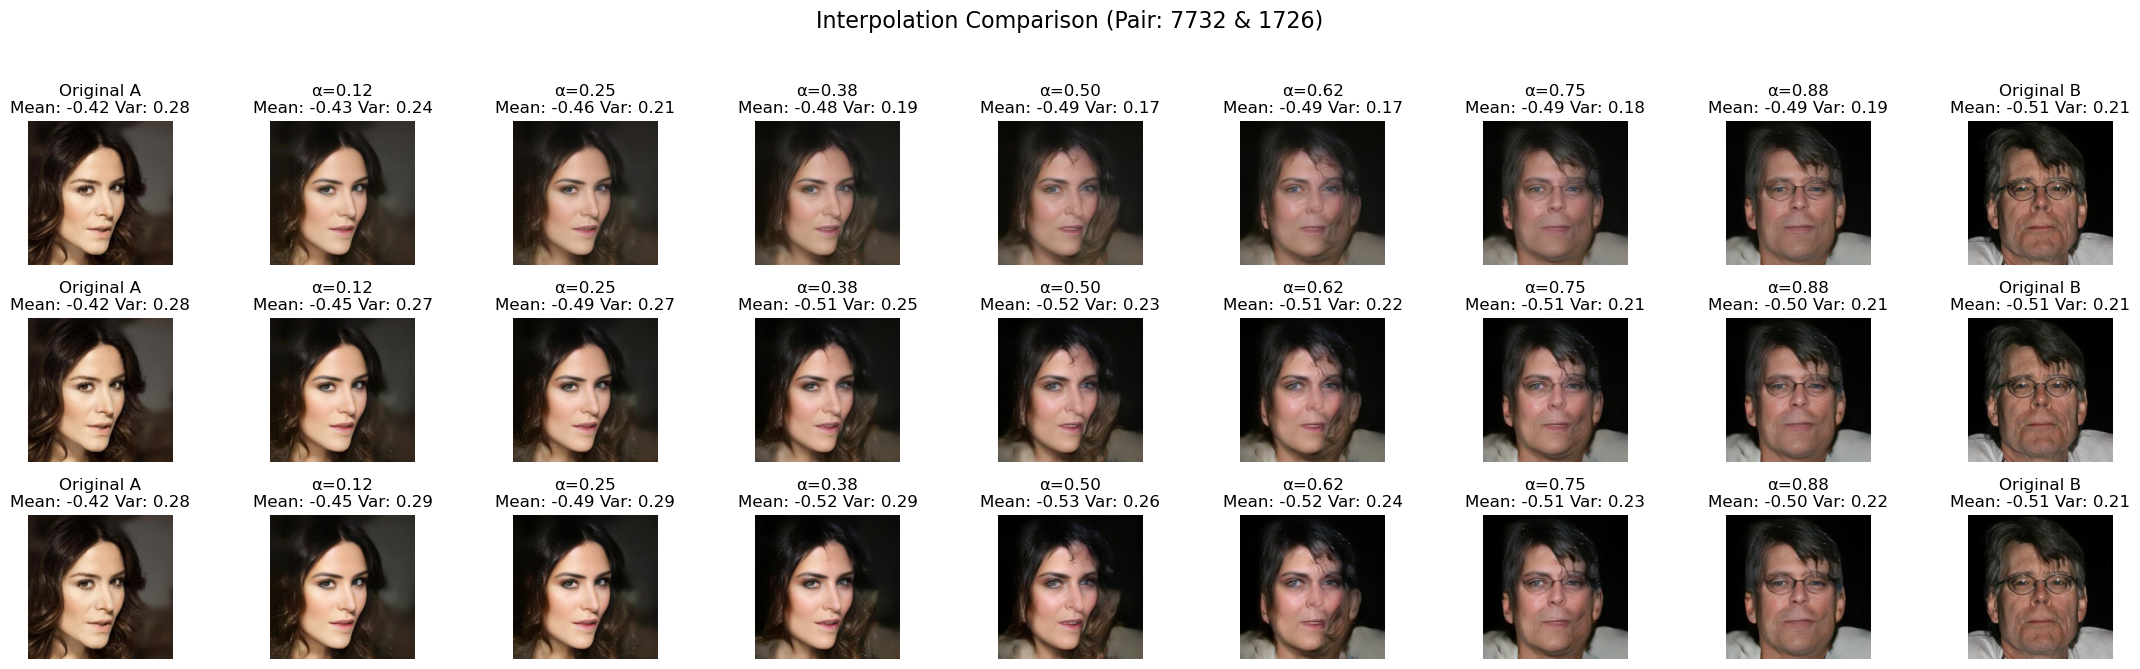

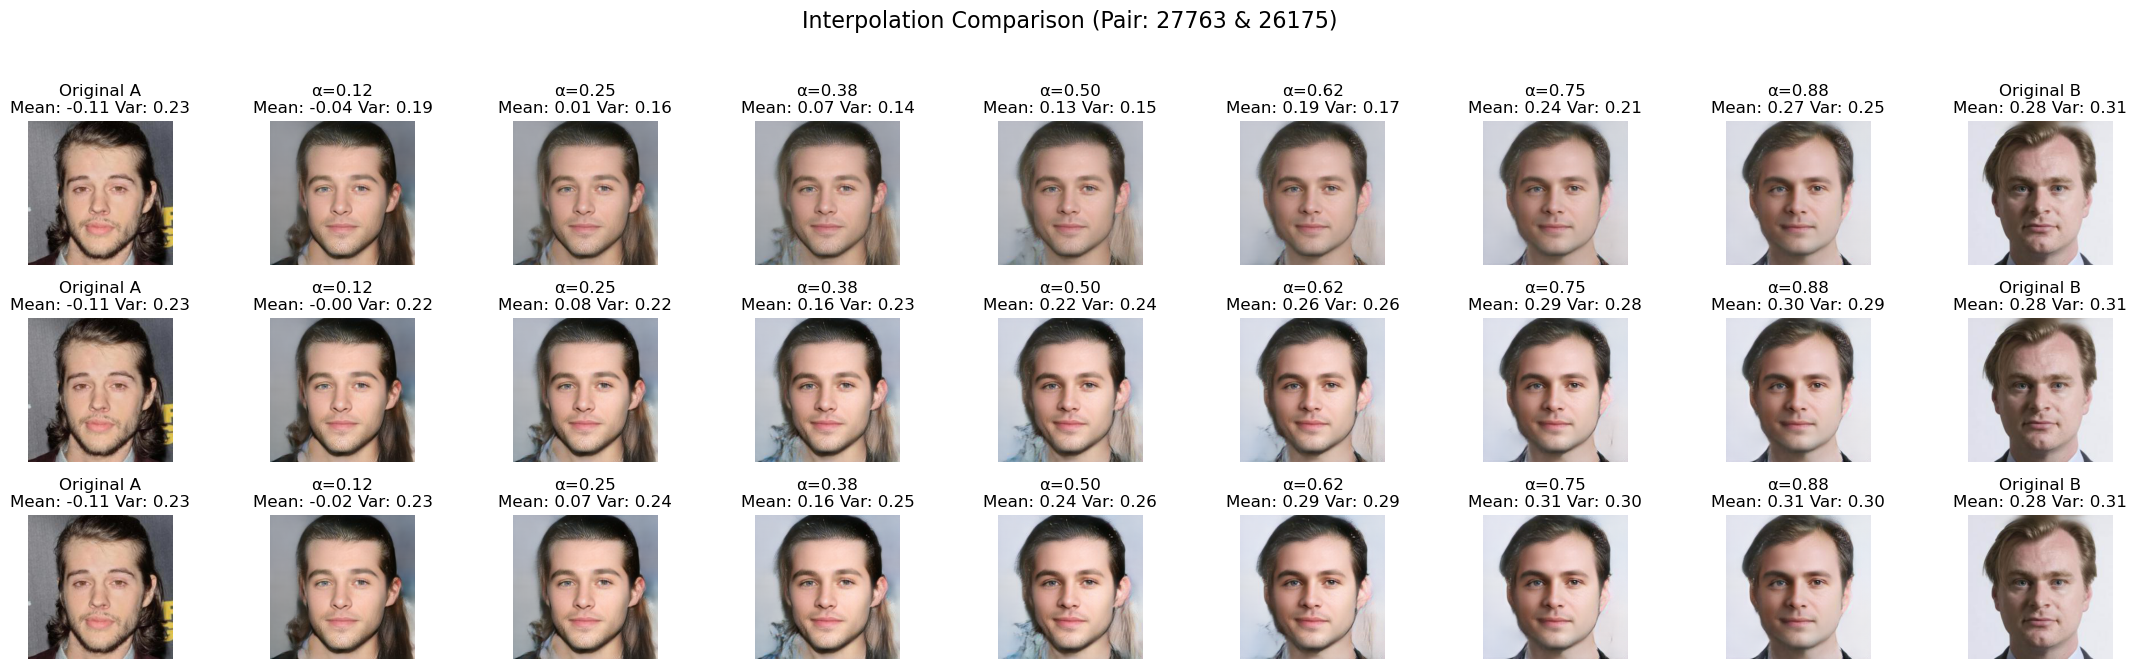

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
import random

# --- 1. 설정 (Settings) ---
DEVICE = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

# 모델 및 데이터 경로
AE_CHECKPOINT_DIR = '/home/nas/data/YMG/superdeep_ae/checkpoints/'
ENCODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'encoder_superdeep_best.pth')
DECODER_PATH = os.path.join(AE_CHECKPOINT_DIR, 'decoder_superdeep_best.pth')
DATA_DIR = '/home/nas/data/YMG/datas/celeba_hq_256/'

# <<< [수정됨] 테스트 이미지 쌍 인덱스 고정 >>>
TEST_PAIRS = [
    (9141, 21742),
    (1857, 17388),
    (9926, 28731),
    (7732, 1726),
    (27763, 26175)
]

# --- 2. 모델 및 헬퍼 함수 정의 (기존과 동일) ---
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels), nn.SiLU(), nn.Conv2d(out_channels, out_channels, 3, 1, 1), nn.BatchNorm2d(out_channels))
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.silu = nn.SiLU()
    def forward(self, x): return self.silu(self.block(x) + self.shortcut(x))

class EncoderSuperDeep(nn.Module):
    def __init__(self, in_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv2d(in_channels, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, base_channels*2, 3, 2, 1), ResBlock(base_channels*2, base_channels*2), nn.Conv2d(base_channels*2, base_channels*4, 3, 2, 1), ResBlock(base_channels*4, base_channels*4), nn.Conv2d(base_channels*4, base_channels*8, 3, 2, 1), ResBlock(base_channels*8, base_channels*8), nn.Conv2d(base_channels*8, base_channels*16, 3, 2, 1), ResBlock(base_channels*16, base_channels*16), nn.Conv2d(base_channels*16, 2 * latent_channels, 3, 1, 1))
    def forward(self, x):
        x = self.encoder(x)
        mu, log_var = torch.chunk(x, 2, dim=1)
        return mu, log_var

class DecoderSuperDeep(nn.Module):
    def __init__(self, out_channels=3, base_channels=128, latent_channels=1):
        super().__init__()
        self.decoder = nn.Sequential(nn.Conv2d(latent_channels, base_channels*16, 3, 1, 1), ResBlock(base_channels*16, base_channels*16), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*16, base_channels*8, 3, 1, 1), ResBlock(base_channels*8, base_channels*8), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*8, base_channels*4, 3, 1, 1), ResBlock(base_channels*4, base_channels*4), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*4, base_channels*2, 3, 1, 1), ResBlock(base_channels*2, base_channels*2), nn.Upsample(scale_factor=2, mode='nearest'), nn.Conv2d(base_channels*2, base_channels, 3, 1, 1), ResBlock(base_channels, base_channels), nn.Conv2d(base_channels, out_channels, 3, 1, 1), nn.Tanh())
    def forward(self, z): return self.decoder(z)

class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.paths = sorted([os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img

def denormalize(tensor):
    return (tensor.clamp(-1, 1) * 0.5) + 0.5

# --- 3. 보간 함수 구현 (기존과 동일) ---
def linear_interpolate(z1, z2, alpha):
    return (1 - alpha) * z1 + alpha * z2

def slerp_interpolate(z1, z2, alpha):
    z1_flat = z1.view(-1)
    z2_flat = z2.view(-1)
    cos_omega = torch.dot(z1_flat, z2_flat) / (torch.norm(z1_flat) * torch.norm(z2_flat))
    cos_omega = torch.clamp(cos_omega, -1.0, 1.0)
    omega = torch.acos(cos_omega)
    sin_omega = torch.sin(omega)
    if sin_omega < 1e-5:
        return linear_interpolate(z1, z2, alpha)
    c1 = torch.sin((1 - alpha) * omega) / sin_omega
    c2 = torch.sin(alpha * omega) / sin_omega
    return c1 * z1 + c2 * z2

def normalized_interpolate(z1, z2, alpha):
    # z_interp = (1 - alpha) * z1 + alpha * z2
    z_interp = linear_interpolate(z1, z2, alpha)
    norm_factor = torch.sqrt((1 - alpha)**2 + alpha**2)
    return z_interp / norm_factor

# --- 4. 메인 테스트 로직 (수정됨) ---
def main():
    # --- 모델 로드 ---
    encoder = EncoderSuperDeep().to(DEVICE); encoder.eval()
    decoder = DecoderSuperDeep().to(DEVICE); decoder.eval()
    encoder.load_state_dict(torch.load(ENCODER_PATH, map_location=DEVICE))
    decoder.load_state_dict(torch.load(DECODER_PATH, map_location=DEVICE))
    print("Pre-trained VAE models loaded successfully.")
    
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    full_dataset = CustomImageDataset(DATA_DIR, transform)

    # --- 3가지 방식 비교 시각화 ---
    total_images = 9 # 양 끝 원본 포함 총 이미지 개수
    num_inter_steps = total_images - 2
    
    # <<< [수정됨] 0과 1을 제외한 중간 alpha 값들만 생성 >>>
    alphas = torch.linspace(0, 1, total_images)[1:-1]

    for start_idx, end_idx in TEST_PAIRS:
        # --- 데이터 준비 ---
        img_a_orig = full_dataset[start_idx] # 원본 이미지 (CPU 텐서)
        img_b_orig = full_dataset[end_idx] # 원본 이미지 (CPU 텐서)

        with torch.no_grad():
            mu_a, _ = encoder(img_a_orig.unsqueeze(0).to(DEVICE))
            mu_b, _ = encoder(img_b_orig.unsqueeze(0).to(DEVICE))

        # 중간 보간 지점들에 대한 잠재 벡터 및 이미지 생성
        lerp_latents = torch.cat([linear_interpolate(mu_a, mu_b, a) for a in alphas], dim=0)
        slerp_latents = torch.cat([slerp_interpolate(mu_a, mu_b, a) for a in alphas], dim=0)
        norm_latents = torch.cat([normalized_interpolate(mu_a, mu_b, a) for a in alphas], dim=0)
        
        with torch.no_grad():
            lerp_images = decoder(lerp_latents).cpu()
            slerp_images = decoder(slerp_latents).cpu()
            norm_images = decoder(norm_latents).cpu()

        # --- 시각화 로직 (수정됨) ---
        fig, axes = plt.subplots(3, total_images, figsize=(22, 7))
        fig.suptitle(f"Interpolation Comparison (Pair: {start_idx} & {end_idx})", fontsize=16)
        
        axes[0, 0].set_ylabel("Linear", fontsize=12)
        axes[1, 0].set_ylabel("Spherical (Slerp)", fontsize=12)
        axes[2, 0].set_ylabel("Normalized", fontsize=12)

        # --- 1. 맨 왼쪽에 원본 이미지 A 표시 ---
        mean_a, var_a = img_a_orig.mean(), img_a_orig.var()
        title_a = f"Original A\nMean: {mean_a:.2f} Var: {var_a:.2f}"
        for i in range(3):
            axes[i, 0].imshow(denormalize(img_a_orig).permute(1, 2, 0))
            axes[i, 0].set_title(title_a)
            axes[i, 0].axis('off')

        # --- 2. 중간에 보간된 이미지들 표시 ---
        for j in range(num_inter_steps):
            # 각 보간 이미지의 평균/분산 계산 및 제목 설정
            mean_l, var_l = lerp_images[j].mean(), lerp_images[j].var()
            axes[0, j + 1].set_title(f"α={alphas[j]:.2f}\nMean: {mean_l:.2f} Var: {var_l:.2f}")
            
            mean_s, var_s = slerp_images[j].mean(), slerp_images[j].var()
            axes[1, j + 1].set_title(f"α={alphas[j]:.2f}\nMean: {mean_s:.2f} Var: {var_s:.2f}")

            mean_n, var_n = norm_images[j].mean(), norm_images[j].var()
            axes[2, j + 1].set_title(f"α={alphas[j]:.2f}\nMean: {mean_n:.2f} Var: {var_n:.2f}")

            # 이미지 출력
            axes[0, j + 1].imshow(denormalize(lerp_images[j]).permute(1, 2, 0))
            axes[1, j + 1].imshow(denormalize(slerp_images[j]).permute(1, 2, 0))
            axes[2, j + 1].imshow(denormalize(norm_images[j]).permute(1, 2, 0))
            
            for i in range(3):
                axes[i, j + 1].axis('off')

        # --- 3. 맨 오른쪽에 원본 이미지 B 표시 ---
        mean_b, var_b = img_b_orig.mean(), img_b_orig.var()
        title_b = f"Original B\nMean: {mean_b:.2f} Var: {var_b:.2f}"
        for i in range(3):
            axes[i, -1].imshow(denormalize(img_b_orig).permute(1, 2, 0))
            axes[i, -1].set_title(title_b)
            axes[i, -1].axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

if __name__ == '__main__':
    main()